In [1]:
# 데이터 분포

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 데이터 로드 mpg
mpg = sns.load_dataset('mpg')
print(f'전체데이터 : {len(mpg)}')
mpg.describe()

전체데이터 : 398


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


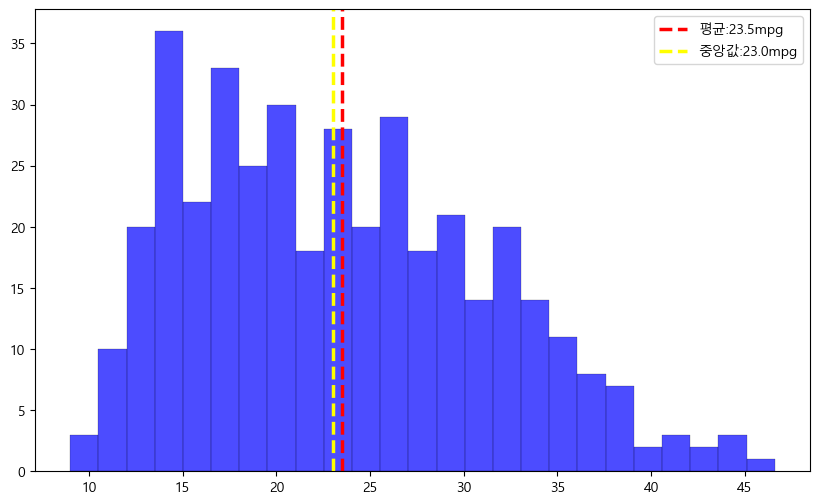

In [ ]:
#연비는 정규분포를 따를까?
# histogram
fig,ax = plt.subplots(figsize=(10,6))
n , bins, patches =  ax.hist(mpg['mpg'],bins=25,edgecolor='black', color='blue',alpha=0.7,linewidth=0.2)
# 평균선 추가
mean_mpg = mpg['mpg'].mean()
ax.axvline(mean_mpg,color='red',linestyle='--',linewidth=2.5,label=f'평균:{mean_mpg:.1f}mpg')
# 중앙선
median_mpg = mpg['mpg'].median()
ax.axvline(median_mpg,color='yellow',linestyle='--',linewidth=2.5,label=f'중앙값:{median_mpg:.1f}mpg')

ax.legend()

# 정규분포는 대칭성  
# 평균 = 중앙값 = 최빈값
# 좌우가 대칭인종모양

# 평균 > 중앙값 - > 우측꼬리가 존재(고연비차량이 존재)  --> 정규분포 아님
# 10 ~20 에집붕... -> 저연비 차량 비중이 높다

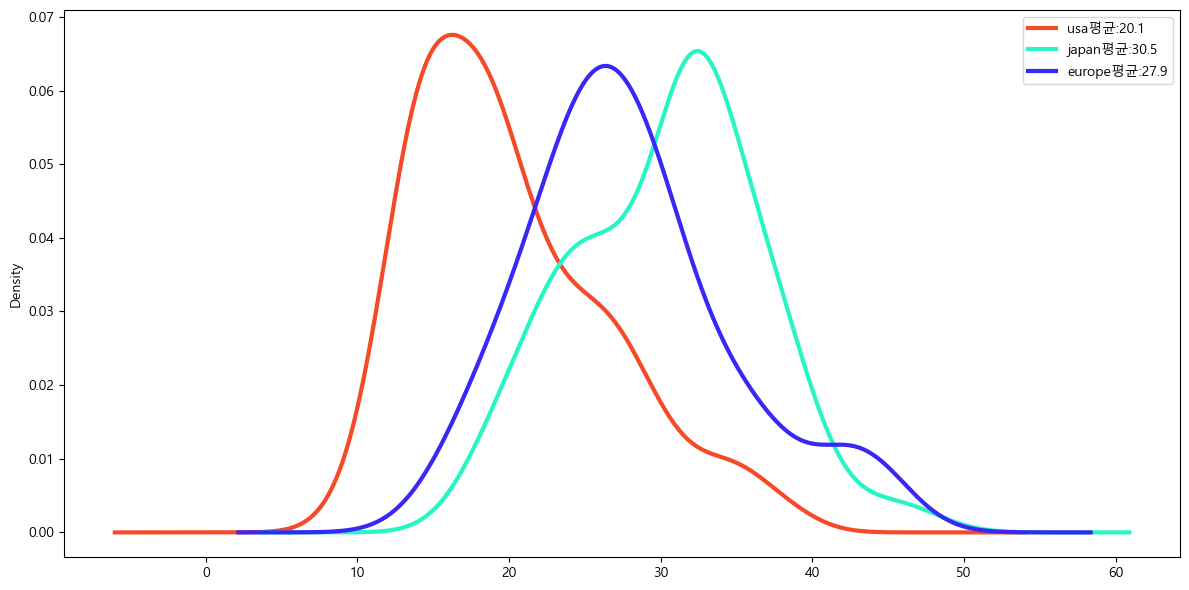

In [ ]:
# 밀도... 부드러운 분포곡선
# 국가별 연비 분포
colors = {
'usa':'#F54927',
'japan':'#27F5C5',
'europe':'#3827F5'
}
fig, ax = plt.subplots(figsize=(12,6))
for origin, color in colors.items():
    data = mpg['origin'] == origin
    data = mpg[data]['mpg']
    data.plot.kde(ax=ax,color=color,linewidth=3, label=f'{origin}평균:{data.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()    
# 

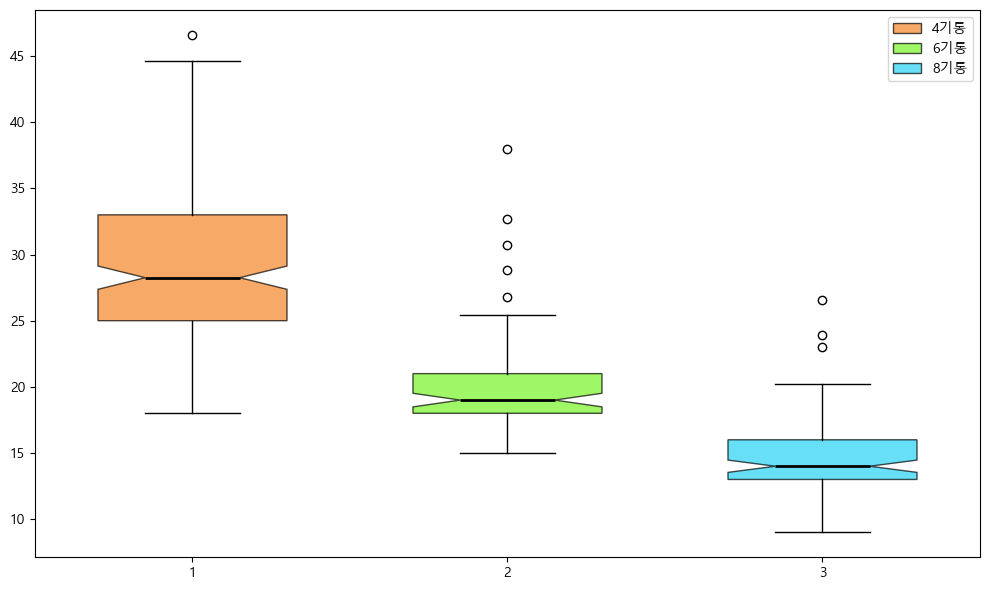

4기통 - 중앙값:28.2 IQR:8.0            이상치개수 : 1
6기통 - 중앙값:19.0 IQR:3.0            이상치개수 : 5
8기통 - 중앙값:14.0 IQR:3.0            이상치개수 : 3


In [40]:
# boxplot : 이상치, 사분위수
# 실린더 수별로 연비편차가 얼마나 다를까?
fig, ax = plt.subplots(figsize=(10,6))
mpg_clean =  mpg[mpg['cylinders'].isin([4,6,8])].copy()

box_data = [  mpg_clean[mpg_clean['cylinders'] == cyl]['mpg']  for cyl in [4,6,8]]
bp = ax.boxplot(box_data,label=['4기통','6기통','8기통'],patch_artist=True,notch=True,widths=0.6)

# box색상
colors = ['#F58727','#76F527','#27D3F5']
for patch,color in zip(bp['boxes'],colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.legend()    

# 중강값선 강조
for median in bp['medians']:
    median.set(color='black', linewidth=2)

plt.tight_layout()
plt.show()

# 통계요약
for cyl in [4,6,8]:
    data = mpg_clean[mpg_clean['cylinders'] == cyl]['mpg']
    q1,q3 = data.quantile([0.25,0.75])
    iqr = q3-q1
    print(f'{cyl}기통 - 중앙값:{data.median():.1f} IQR:{iqr:.1f} \
           이상치개수 : { len(data[(data > q3+1.5*iqr) | (data < q1 - 1.5*iqr)] ) }' )

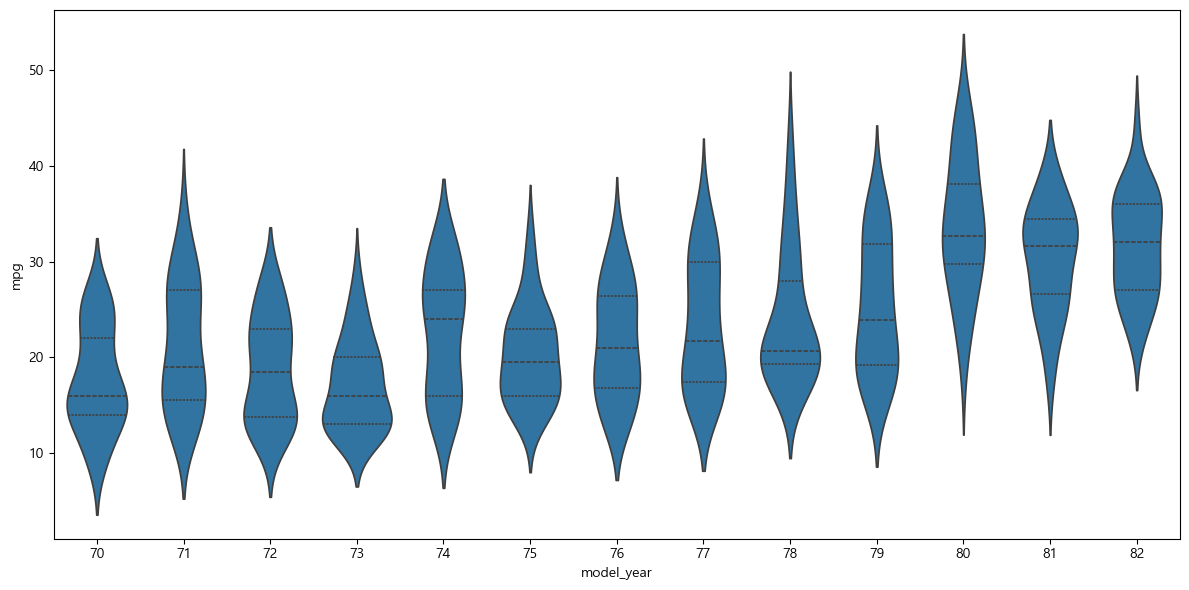

In [44]:
# violineplot 분포형태
# 연식에 따라 연비가분포가 어떻게 진화했는지?
fig, ax = plt.subplots(figsize=(12,6))
sns.violinplot(data=mpg, x='model_year', y='mpg',ax=ax,inner='quartitle')
plt.tight_layout()
plt.show()